DEVICE: cuda
IMG_SIZE: 256x256
Preprocessing complete. Sharp images saved.


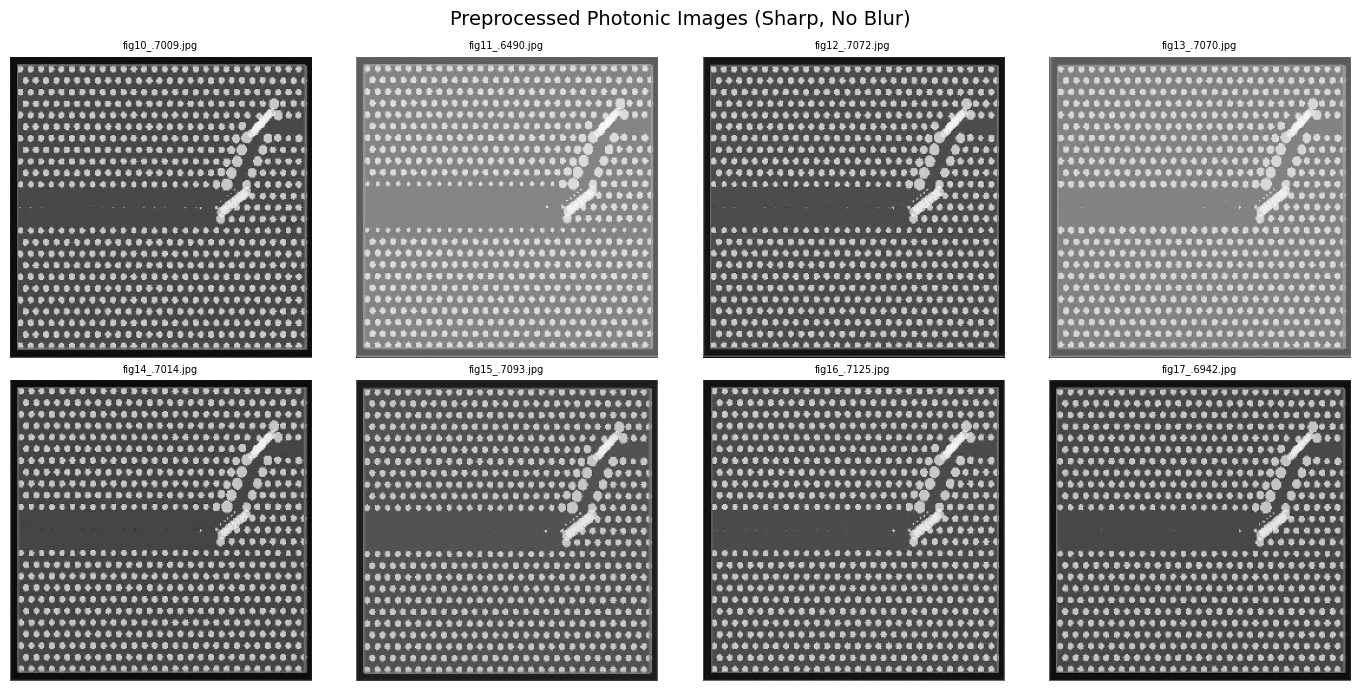

Dataset size: 34 images
Generator params:  13,275,584
Critic params:     11,194,785
Epoch [001/300] Critic: -20.1397  Gen: 7.4287  Avg Critic: 376.2895
Epoch [002/300] Critic: -82.2589  Gen: 42.3700  Avg Critic: -43.9718
Epoch [003/300] Critic: -139.3377  Gen: 70.7307  Avg Critic: -100.9371
Epoch [004/300] Critic: -136.8409  Gen: 70.7391  Avg Critic: -137.6306
Epoch [005/300] Critic: -130.6576  Gen: 64.0762  Avg Critic: -129.0627
Epoch [006/300] Critic: -119.8101  Gen: 59.1623  Avg Critic: -118.2608
Epoch [007/300] Critic: -102.7896  Gen: 72.3530  Avg Critic: -117.8284
Epoch [008/300] Critic: -113.9669  Gen: 69.9205  Avg Critic: -114.2043
Epoch [009/300] Critic: -115.9278  Gen: 44.5120  Avg Critic: -117.6754
Epoch [010/300] Critic: -122.9030  Gen: 60.8750  Avg Critic: -103.6719
  -> Checkpoint saved at epoch 10 (critic loss: -103.6719)
Epoch [011/300] Critic: -135.7440  Gen: 73.4358  Avg Critic: -112.2963
Epoch [012/300] Critic: -113.9291  Gen: 66.2162  Avg Critic: -108.9125
Epoch [013

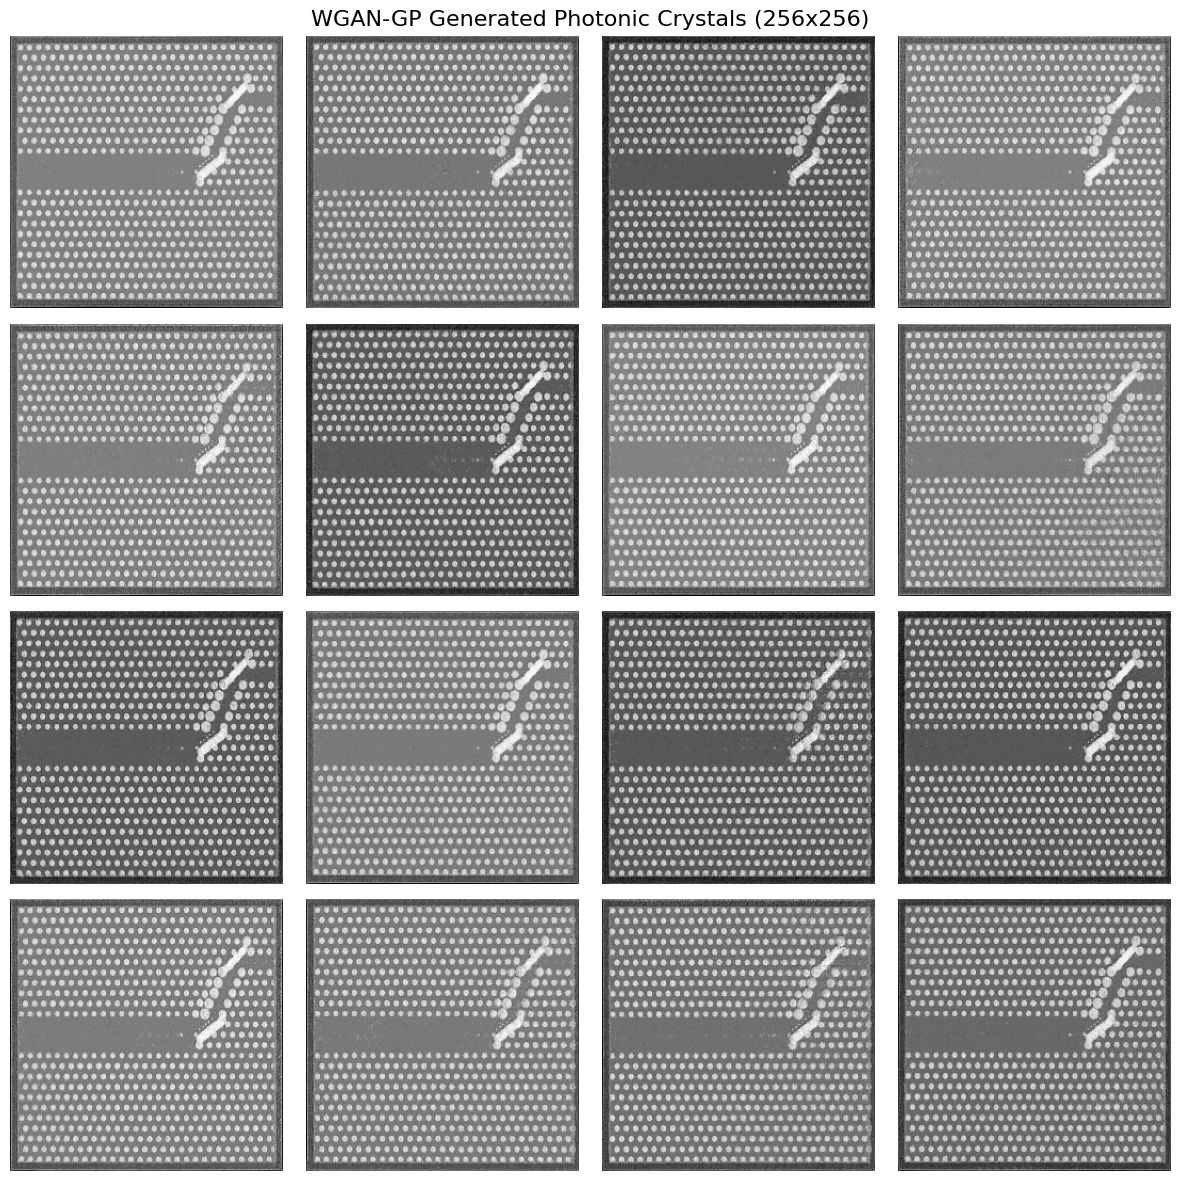

Sample grid saved.


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets

from torchvision import transforms
from torchvision.utils import save_image
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.benchmark = True

# =========================
# CONFIG
# =========================

DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE       = 256        # upgraded from 128
IMG_CHANNELS   = 1
BATCH_SIZE     = 4          # reduced from 8 to fit 256x256 in 6GB VRAM
NOISE_DIM      = 128
FEATURE_GEN    = 32
FEATURE_CRITIC = 32
LR             = 5e-5
EPOCHS         = 300
CRITIC_ITER    = 5
LAMBDA_GP      = 10

print(f"DEVICE: {DEVICE}")
print(f"IMG_SIZE: {IMG_SIZE}x{IMG_SIZE}")

# =========================
# PREPROCESSING
# FIX: No GaussianBlur, No equalizeHist
# Just resize + save. Model learns from clean sharp images.
# =========================

INPUT_FOLDER  = "photonic_images/classA"
OUTPUT_FOLDER = "processed_photonic/classA"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

for file in os.listdir(INPUT_FOLDER):

    path = os.path.join(INPUT_FOLDER, file)
    img  = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Warning: Could not read {file}, skipping.")
        continue

    # Resize to 256x256 — no blurring, no histogram equalization
    img = cv2d = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LANCZOS4)

    cv2.imwrite(os.path.join(OUTPUT_FOLDER, file), img)

print("Preprocessing complete. Sharp images saved.")

# =========================
# VERIFY PREPROCESSED IMAGES
# =========================

files = os.listdir(OUTPUT_FOLDER)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flatten()):
    if i >= len(files):
        ax.axis("off")
        continue
    img = cv2.imread(os.path.join(OUTPUT_FOLDER, files[i]), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap="gray")
    ax.set_title(files[i][:15], fontsize=7)
    ax.axis("off")

plt.suptitle("Preprocessed Photonic Images (Sharp, No Blur)", fontsize=14)
plt.tight_layout()
plt.show()

# =========================
# TRANSFORMS
# =========================

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])   # maps [0,1] -> [-1,1] for Tanh output
])

# =========================
# DATASET
# =========================

dataset = datasets.ImageFolder(
    root="processed_photonic",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=2,
    drop_last=True
)

print(f"Dataset size: {len(dataset)} images")

# =========================
# GENERATOR
# Upgraded: 1x1 -> 256x256 (7 blocks instead of 6)
# =========================

class Generator(nn.Module):

    def __init__(self, noise_dim, channels_img, features_g):
        super().__init__()

        self.net = nn.Sequential(

            # 1x1 -> 4x4
            self._block(noise_dim, features_g * 32, 4, 1, 0),

            # 4x4 -> 8x8
            self._block(features_g * 32, features_g * 16, 4, 2, 1),

            # 8x8 -> 16x16
            self._block(features_g * 16, features_g * 8, 4, 2, 1),

            # 16x16 -> 32x32
            self._block(features_g * 8, features_g * 4, 4, 2, 1),

            # 32x32 -> 64x64
            self._block(features_g * 4, features_g * 2, 4, 2, 1),

            # 64x64 -> 128x128
            self._block(features_g * 2, features_g, 4, 2, 1),

            # 128x128 -> 256x256  (NEW block for higher resolution)
            nn.ConvTranspose2d(
                features_g,
                channels_img,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.Tanh()
        )

    def _block(self, in_c, out_c, kernel, stride, pad):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel, stride, pad, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(True)
        )

    def forward(self, x):
        x = x.view(x.shape[0], x.shape[1], 1, 1)
        return self.net(x)


# =========================
# CRITIC
# FIX: Removed spectral norm — it conflicts with gradient penalty in WGAN-GP
# Added one extra block for 256x256 input
# =========================

class Critic(nn.Module):

    def __init__(self, channels_img, features_d):
        super().__init__()

        self.net = nn.Sequential(

            # 256x256 -> 128x128
            nn.Conv2d(channels_img, features_d, 4, 2, 1),
            nn.LeakyReLU(0.2),

            # 128x128 -> 64x64  (NEW block for higher resolution)
            self._block(features_d,      features_d * 2),

            # 64x64 -> 32x32
            self._block(features_d * 2,  features_d * 4),

            # 32x32 -> 16x16
            self._block(features_d * 4,  features_d * 8),

            # 16x16 -> 8x8
            self._block(features_d * 8,  features_d * 16),

            # 8x8 -> 4x4
            self._block(features_d * 16, features_d * 32),

            # 4x4 -> 1x1
            nn.Conv2d(features_d * 32, 1, kernel_size=4, stride=1, padding=0)
        )

    def _block(self, in_c, out_c):
        # No spectral norm — WGAN-GP handles stability via gradient penalty
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_c, affine=True),  # InstanceNorm works better than BatchNorm in critic
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.net(x).reshape(-1)


# =========================
# WEIGHT INIT
# =========================

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        if isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)


# =========================
# GRADIENT PENALTY
# =========================

def gradient_penalty(critic, real, fake, device):

    B, C, H, W = real.shape

    epsilon = torch.rand(B, 1, 1, 1).repeat(1, C, H, W).to(device)

    interpolated = real * epsilon + fake * (1 - epsilon)
    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated)

    gradient = torch.autograd.grad(
        inputs=interpolated,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True
    )[0]

    gradient      = gradient.reshape(B, -1)
    gradient_norm = gradient.norm(2, dim=1)
    gp            = torch.mean((gradient_norm - 1) ** 2)

    return gp


# =========================
# INIT MODELS
# =========================

gen    = Generator(NOISE_DIM, IMG_CHANNELS, FEATURE_GEN).to(DEVICE)
critic = Critic(IMG_CHANNELS, FEATURE_CRITIC).to(DEVICE)

initialize_weights(gen)
initialize_weights(critic)

opt_gen    = optim.Adam(gen.parameters(),    lr=LR, betas=(0.0, 0.9))
opt_critic = optim.Adam(critic.parameters(), lr=LR, betas=(0.0, 0.9))

fixed_noise = torch.randn(16, NOISE_DIM).to(DEVICE)

print(f"Generator params:  {sum(p.numel() for p in gen.parameters()):,}")
print(f"Critic params:     {sum(p.numel() for p in critic.parameters()):,}")

# =========================
# TENSORBOARD
# =========================

writer_real = SummaryWriter("logs/real")
writer_fake = SummaryWriter("logs/fake")

step = 0

# =========================
# CHECKPOINT SETUP
# Save best model during training so you don't
# have to wait for full 300 epochs
# =========================

os.makedirs("checkpoints", exist_ok=True)
best_critic_loss = float("-inf")

# =========================
# TRAINING LOOP
# =========================

gen.train()
critic.train()

for epoch in range(EPOCHS):

    epoch_critic_loss = 0

    for batch_idx, (real, _) in enumerate(loader):

        real          = real.to(DEVICE)
        cur_batch     = real.shape[0]

        # ---- TRAIN CRITIC ----
        for _ in range(CRITIC_ITER):

            noise        = torch.randn(cur_batch, NOISE_DIM).to(DEVICE)
            fake         = gen(noise)

            critic_real  = critic(real)
            critic_fake  = critic(fake.detach())

            gp           = gradient_penalty(critic, real, fake.detach(), DEVICE)

            loss_critic  = -(torch.mean(critic_real) - torch.mean(critic_fake)) + LAMBDA_GP * gp

            critic.zero_grad()
            loss_critic.backward()
            opt_critic.step()

        epoch_critic_loss += loss_critic.item()

        # ---- TRAIN GENERATOR ----
        noise     = torch.randn(cur_batch, NOISE_DIM).to(DEVICE)
        fake      = gen(noise)
        gen_fake  = critic(fake)
        loss_gen  = -torch.mean(gen_fake)

        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

    # ---- LOGGING ----
    avg_critic = epoch_critic_loss / len(loader)

    print(
        f"Epoch [{epoch+1:03d}/{EPOCHS}] "
        f"Critic: {loss_critic:.4f}  "
        f"Gen: {loss_gen:.4f}  "
        f"Avg Critic: {avg_critic:.4f}"
    )

    # ---- TENSORBOARD + CHECKPOINT every 10 epochs ----
    if (epoch + 1) % 10 == 0:

        with torch.no_grad():

            fake_samples = gen(fixed_noise)
            fake_samples = fake_samples * 0.5 + 0.5   # denormalize to [0,1]

            real_grid = torchvision.utils.make_grid(real[:4], normalize=True)
            fake_grid = torchvision.utils.make_grid(fake_samples[:4], normalize=True)

            writer_real.add_image("Real", real_grid, global_step=step)
            writer_fake.add_image("Fake", fake_grid, global_step=step)
            step += 1

        # Save checkpoint if critic loss improved (less negative = better convergence)
        if avg_critic > best_critic_loss:
            best_critic_loss = avg_critic
            torch.save({
                "epoch":            epoch,
                "gen_state":        gen.state_dict(),
                "critic_state":     critic.state_dict(),
                "opt_gen_state":    opt_gen.state_dict(),
                "opt_critic_state": opt_critic.state_dict(),
                "critic_loss":      avg_critic
            }, "checkpoints/best_model.pt")
            print(f"  -> Checkpoint saved at epoch {epoch+1} (critic loss: {avg_critic:.4f})")

# Always save final model
torch.save({
    "epoch":        EPOCHS,
    "gen_state":    gen.state_dict(),
    "critic_state": critic.state_dict(),
}, "checkpoints/final_model.pt")

print("Training complete.")

# =========================
# GENERATE & SAVE 200 IMAGES
# =========================

os.makedirs("generated_images", exist_ok=True)

gen.eval()

with torch.no_grad():

    noise       = torch.randn(200, NOISE_DIM).to(DEVICE)
    fake_images = gen(noise)
    fake_images = (fake_images * 0.5 + 0.5).clamp(0, 1)

    for i in range(200):
        save_image(fake_images[i], f"generated_images/generated_{i}.png")

print("200 images saved to generated_images/")

# =========================
# VISUALIZE 16 SAMPLES
# =========================

gen.eval()

with torch.no_grad():
    noise   = torch.randn(16, NOISE_DIM).to(DEVICE)
    samples = gen(noise)
    samples = (samples * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i].cpu().squeeze(), cmap="gray")
    ax.axis("off")

plt.suptitle("WGAN-GP Generated Photonic Crystals (256x256)", fontsize=16)
plt.tight_layout()
plt.savefig("generated_images/sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sample grid saved.")